# Detector performance by family, tier & variant

Analyzes a DetectZoo per-image report (`file, true_label, score, class`) and breaks performance down by
the structure encoded in the **manipulated** filenames:

```
item_<number>_<family>_<tier>_<split>_<variant>.png
        00170    cctv     T1     test      C
```

### How performance is measured here
The report has a **score** (higher = more likely manipulated) but no fixed threshold, so:
- **Recall @ threshold** — share of a group's manipulated images flagged as fake. The threshold is chosen
  from the data (Youden's J, maximizing TPR − FPR over real vs fake). You can override it.
- **AUC vs. real** — each group's manipulated images (positives) against **all** authentic images
  (negatives). Threshold-free and the more robust per-group comparison. (A group of only fakes has no
  internal AUC, hence comparing against the shared real set.)

Group sizes matter: a recall built on 4 images is noisy. The `n` column is always shown.


## 1. Configuration

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

CSV_PATH = Path(r"C:\Users\kelly.mcconvey\Documents\GitHub\Synthetic-Evidence-Image-Corpus\detectzoo_results\per_image_d3.csv")

# Operating threshold: None -> pick optimal (Youden's J) from the data; or set a float to override.
THRESHOLD = None

DETECTOR = CSV_PATH.stem.replace("per_image_", "")
OUT_DIR = CSV_PATH.parent / f"analysis_{DETECTOR}"
OUT_DIR.mkdir(exist_ok=True)
print("Detector:", DETECTOR, "| output ->", OUT_DIR)

Detector: d3 | output -> C:\Users\kelly.mcconvey\Documents\GitHub\Synthetic-Evidence-Image-Corpus\detectzoo_results\analysis_d3


## 2. Load report and parse filenames

In [2]:
def parse_fake_filename(fname):
    """item_<num>_<family>_<tier>_<split>_<variant>.ext  (family may contain underscores)."""
    stem = str(fname).rsplit(".", 1)[0]
    toks = stem.split("_")
    if len(toks) >= 6 and toks[0] == "item":
        return dict(item=toks[1], family="_".join(toks[2:-3]),
                    tier=toks[-3], split=toks[-2], variant=toks[-1])
    return dict(item=None, family=None, tier=None, split=None, variant=None)

df = pd.read_csv(CSV_PATH)
df["true_label"] = df["true_label"].astype(int)
df["score"] = df["score"].astype(float)

parsed = df["file"].apply(parse_fake_filename).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

fakes = df[df.true_label == 1].copy()
reals = df[df.true_label == 0].copy()

n_unparsed = int(fakes["family"].isna().sum())
print(f"Total rows : {len(df)}")
print(f"Real (0)   : {len(reals)}")
print(f"Fake (1)   : {len(fakes)}   (parsed: {len(fakes) - n_unparsed}, unparsed: {n_unparsed})")
if n_unparsed:
    print("\nExamples of fake filenames that did NOT match the pattern:")
    print(fakes[fakes.family.isna()]["file"].head(10).to_string(index=False))

# keep only successfully parsed fakes for the breakdowns
fakes = fakes[fakes.family.notna()].copy()
df.head()

Total rows : 1505
Real (0)   : 720
Fake (1)   : 785   (parsed: 785, unparsed: 0)


,file,true_label,score,class,item,family,tier,split,variant
0,bdd100k_0049e5b8-afda7206.png,0,0.019903,real,None,None,None,None,None
1,bdd100k_00d0f034-6d666f7b.png,0,0.160069,real,None,None,None,None,None
2,bdd100k_00e9be89-00000160.png,0,0.982360,real,None,None,None,None,None
3,bdd100k_00e9be89-00001640.png,0,0.368731,real,None,None,None,None,None
4,bdd100k_019d0e2f-26b8c896.png,0,0.332354,real,None,None,None,None,None


## 3. Metrics helpers, threshold & overall numbers

In [3]:
def _average_ranks(a):
    a = np.asarray(a, float); n = len(a)
    order = a.argsort(); sa = a[order]; ranks = np.empty(n, float); i = 0
    while i < n:
        j = i
        while j + 1 < n and sa[j + 1] == sa[i]:
            j += 1
        ranks[order[i:j + 1]] = (i + j) / 2.0 + 1.0
        i = j + 1
    return ranks

def rank_auc(scores, labels):
    """AUROC via Mann-Whitney (ties = 0.5). No sklearn dependency."""
    scores = np.asarray(scores, float); labels = np.asarray(labels, int)
    n_pos = int((labels == 1).sum()); n_neg = int((labels == 0).sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    r = _average_ranks(scores)
    return float((r[labels == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

def youden_threshold(scores, labels):
    scores = np.asarray(scores, float); labels = np.asarray(labels, int)
    P = int((labels == 1).sum()); N = int((labels == 0).sum())
    if P == 0 or N == 0:
        return float(np.median(scores))
    best_t, best_j = float(scores.min()), -np.inf
    for t in np.unique(scores):
        pred = scores >= t
        j = (pred & (labels == 1)).sum() / P - (pred & (labels == 0)).sum() / N
        if j > best_j:
            best_j, best_t = j, float(t)
    return best_t

def tier_key(t):
    m = re.match(r"[A-Za-z]*(\d+)", str(t))
    return (int(m.group(1)) if m else 10**9, str(t))

THR = float(THRESHOLD) if THRESHOLD is not None else youden_threshold(df.score.values, df.true_label.values)
NEG = reals.score.values   # all authentic images = shared negative pool

overall_auc = rank_auc(df.score, df.true_label)
overall_recall = float((fakes.score.values >= THR).mean())
fpr = float((reals.score.values >= THR).mean())
print(f"Operating threshold : {THR:.4f}  ({'data-chosen' if THRESHOLD is None else 'manual'})")
print(f"Overall AUC         : {overall_auc:.4f}")
print(f"Overall recall@thr  : {overall_recall:.3f}  (fakes flagged)")
print(f"False-positive rate : {fpr:.3f}  (reals flagged)")

Operating threshold : 0.2779  (data-chosen)
Overall AUC         : 0.6739
Overall recall@thr  : 0.559  (fakes flagged)
False-positive rate : 0.279  (reals flagged)


## 4. Breakdown helper

In [4]:
def grouped_stats(frame, by):
    """Per-group n, recall@THR, score stats, and AUC vs. all real images. Version-agnostic."""
    out = []
    for key, g in frame.groupby(by, dropna=False):
        s = np.concatenate([g.score.values, NEG])
        l = np.concatenate([np.ones(len(g)), np.zeros(len(NEG))])
        out.append({
            by: key,
            "n": len(g),
            "recall": float((g.score.values >= THR).mean()),
            "mean_score": float(g.score.mean()),
            "median_score": float(g.score.median()),
            "auc_vs_real": rank_auc(s, l),
        })
    res = pd.DataFrame(out)
    sort_col = "auc_vs_real"
    if by == "tier":
        res = res.sort_values(by, key=lambda c: c.map(tier_key))
    else:
        res = res.sort_values(sort_col)
    return res.reset_index(drop=True)

## 5. By tier

In [5]:
by_tier = grouped_stats(fakes, "tier")
by_tier.to_csv(OUT_DIR / "by_tier.csv", index=False)
by_tier.round(4)

,tier,n,recall,mean_score,median_score,auc_vs_real
0,T1,349,0.5215,0.4653,0.3420,0.6510
1,T2,301,0.5947,0.5009,0.4618,0.7017
2,T3,135,0.5778,0.4947,0.4553,0.6712


## 6. By family

In [6]:
by_family = grouped_stats(fakes, "family")
by_family.to_csv(OUT_DIR / "by_family.csv", index=False)
by_family.round(4)

,family,n,recall,mean_score,median_score,auc_vs_real
0,dashcam,255,0.3529,0.3099,0.0781,0.5476
1,cctv,264,0.5758,0.4995,0.4464,0.6922
2,phone,266,0.7406,0.6356,0.8181,0.7768


## 7. By variant

In [7]:
by_variant = grouped_stats(fakes, "variant")
by_variant.to_csv(OUT_DIR / "by_variant.csv", index=False)
by_variant.round(4)

,variant,n,recall,mean_score,median_score,auc_vs_real
0,B,257,0.4591,0.3900,0.1945,0.6126
1,A,267,0.5094,0.4305,0.2955,0.6281
2,Photoshop,3,0.3333,0.2311,0.1763,0.6384
3,C,253,0.7115,0.6349,0.8427,0.7818
4,ChatGPT,5,0.8000,0.6862,0.7983,0.8350


## 8. Family x tier matrices

Recall and AUC for every family/tier cell. Empty cells = no images.

In [8]:
fakes = fakes.assign(detected=fakes.score >= THR)
tier_order = sorted(fakes.tier.unique(), key=tier_key)

recall_mat = (fakes.pivot_table(index="family", columns="tier", values="detected", aggfunc="mean")
                   .reindex(columns=tier_order))
count_mat  = (fakes.pivot_table(index="family", columns="tier", values="detected", aggfunc="count")
                   .reindex(columns=tier_order))

def _auc_cell(g):
    s = np.concatenate([g.score.values, NEG]); l = np.concatenate([np.ones(len(g)), np.zeros(len(NEG))])
    return rank_auc(s, l)
auc_mat = (fakes.groupby(["family", "tier"]).apply(_auc_cell)
                .unstack("tier").reindex(columns=tier_order))

recall_mat.to_csv(OUT_DIR / "recall_family_x_tier.csv")
auc_mat.to_csv(OUT_DIR / "auc_family_x_tier.csv")

print("Recall (family x tier):")
display(recall_mat.round(3))
print("Sample count (family x tier):")
display(count_mat.fillna(0).astype(int))

Recall (family x tier):


C:\Users\kelly.mcconvey\AppData\Local\Temp\ipykernel_14272\2472819387.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_mat = (fakes.groupby(["family", "tier"]).apply(_auc_cell)


tier,T1,T2,T3
family,,,
cctv,0.513,0.637,0.600
dashcam,0.339,0.398,0.289
phone,0.700,0.743,0.844


Sample count (family x tier):


tier,T1,T2,T3
family,,,
cctv,117,102,45
dashcam,112,98,45
phone,120,101,45


## 9. Heatmaps & score distributions

Saved as PNGs next to the CSVs.

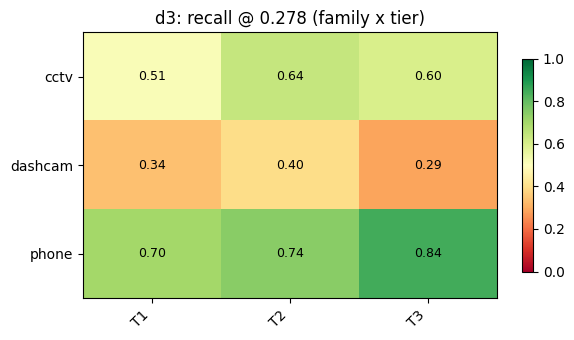

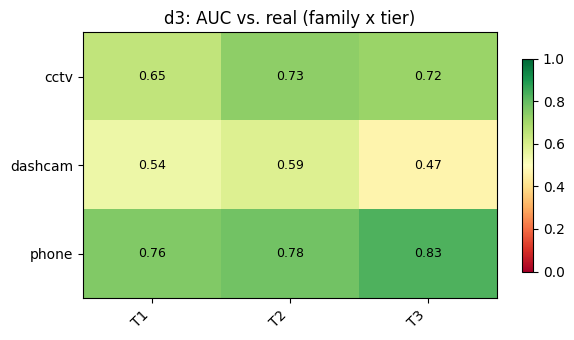

C:\Users\kelly.mcconvey\AppData\Local\Temp\ipykernel_14272\55124773.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=tier_order, showfliers=False)


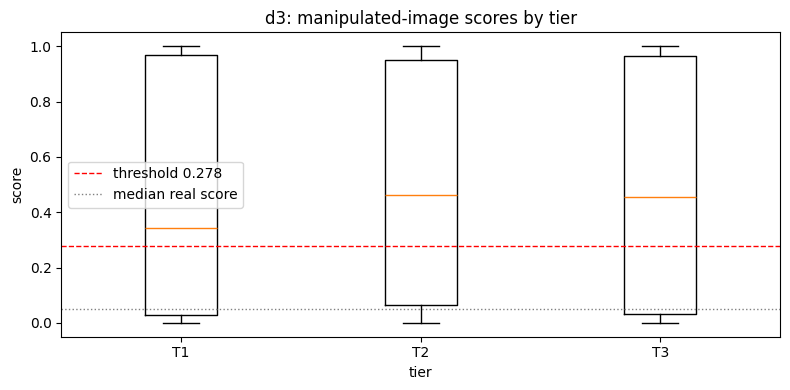

In [9]:
import matplotlib.pyplot as plt   # notebook inline backend; do NOT force "Agg" (that triggers the non-interactive warning)

def heatmap(mat, title, fname, fmt="{:.2f}", vmin=0, vmax=1):
    fig, ax = plt.subplots(figsize=(1.4 * mat.shape[1] + 2, 0.5 * mat.shape[0] + 2))
    im = ax.imshow(mat.values.astype(float), aspect="auto", vmin=vmin, vmax=vmax, cmap="RdYlGn")
    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=9)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout(); fig.savefig(OUT_DIR / fname, dpi=130); plt.show()

heatmap(recall_mat, f"{DETECTOR}: recall @ {THR:.3f} (family x tier)", "heatmap_recall.png")
heatmap(auc_mat,    f"{DETECTOR}: AUC vs. real (family x tier)",       "heatmap_auc.png")

# Score distribution by tier (manipulated images), with the threshold line and the real-image band.
fig, ax = plt.subplots(figsize=(8, 4))
data = [fakes[fakes.tier == t].score.values for t in tier_order]
ax.boxplot(data, labels=tier_order, showfliers=False)
ax.axhline(THR, color="red", ls="--", lw=1, label=f"threshold {THR:.3f}")
ax.axhline(np.median(NEG), color="gray", ls=":", lw=1, label="median real score")
ax.set_xlabel("tier"); ax.set_ylabel("score"); ax.set_title(f"{DETECTOR}: manipulated-image scores by tier")
ax.legend(); fig.tight_layout(); fig.savefig(OUT_DIR / "scores_by_tier.png", dpi=130); plt.show()

## 10. Hardest-to-detect manipulations

Lowest-scoring manipulated images overall, and the weakest family/tier cells — the gaps to look at.

In [10]:
cols = ["file", "family", "tier", "variant", "score"]
print("Lowest-scoring manipulated images:")
display(fakes.nsmallest(15, "score")[cols].reset_index(drop=True))

print("\nWeakest family x tier cells by recall (min 3 images):")
weak = (fakes.groupby(["family", "tier"])
             .agg(n=("score", "size"), recall=("detected", "mean"), mean_score=("score", "mean"))
             .reset_index())
weak = weak[weak.n >= 3].sort_values("recall").head(15).reset_index(drop=True)
display(weak.round(3))

# Combined per-image table with parsed fields for any further slicing.
fakes[["file", "item", "family", "tier", "split", "variant", "score", "detected"]] \
    .to_csv(OUT_DIR / "fakes_parsed.csv", index=False)
print("\nSaved all CSVs and PNGs to:", OUT_DIR)

Lowest-scoring manipulated images:


,file,family,tier,variant,score
0,item_00347_dashcam_T2_train_A.png,dashcam,T2,A,0.000131
1,item_00046_cctv_T1_train_B.png,cctv,T1,B,0.000265
2,item_00382_dashcam_T2_train_A.png,dashcam,T2,A,0.000384
3,item_00003_cctv_T1_train_A.png,cctv,T1,A,0.000395
4,item_00291_dashcam_T1_train_B.png,dashcam,T1,B,0.000486
5,item_00774_dashcam_T3_train_A.png,dashcam,T3,A,0.000500
6,item_00408_dashcam_T1_test_B.png,dashcam,T1,B,0.000638
7,item_00775_dashcam_T3_train_A.png,dashcam,T3,A,0.000927
8,item_00476_dashcam_T2_test_C.png,dashcam,T2,C,0.001018
9,item_00290_dashcam_T1_train_A.png,dashcam,T1,A,0.001164



Weakest family x tier cells by recall (min 3 images):


,family,tier,n,recall,mean_score
0,dashcam,T3,45,0.289,0.259
1,dashcam,T1,112,0.339,0.307
2,dashcam,T2,98,0.398,0.337
3,cctv,T1,117,0.513,0.472
4,cctv,T3,45,0.600,0.507
5,cctv,T2,102,0.637,0.528
6,phone,T1,120,0.700,0.607
7,phone,T2,101,0.743,0.633
8,phone,T3,45,0.844,0.718



Saved all CSVs and PNGs to: C:\Users\kelly.mcconvey\Documents\GitHub\Synthetic-Evidence-Image-Corpus\detectzoo_results\analysis_d3


## 11. Hero images

The nine **hero** images (any filename containing `hero`). For each: its true class, score, whether it's flagged as manipulated at the operating threshold, and whether that call is correct. Lower scores on manipulated heroes = closer to slipping past the detector.

Hero images found : 8  (8 manipulated, 0 authentic)
Recall @ 0.278  : 0.625  (manipulated heroes flagged)
Mean score        : 0.5155
Accuracy (heroes) : 0.625


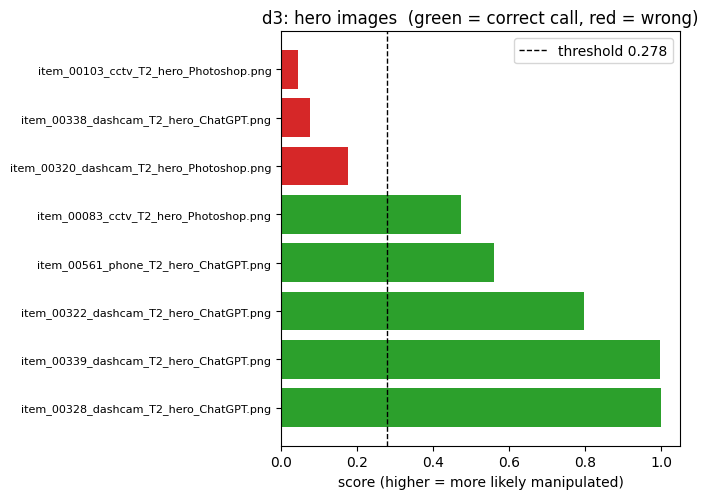

,file,class,true_label,family,tier,variant,score,flagged_ai,correct
0,item_00103_cctv_T2_hero_Photoshop.png,fake,1,cctv,T2,Photoshop,0.0436,False,False
1,item_00338_dashcam_T2_hero_ChatGPT.png,fake,1,dashcam,T2,ChatGPT,0.0759,False,False
2,item_00320_dashcam_T2_hero_Photoshop.png,fake,1,dashcam,T2,Photoshop,0.1763,False,False
3,item_00083_cctv_T2_hero_Photoshop.png,fake,1,cctv,T2,Photoshop,0.4734,True,True
4,item_00561_phone_T2_hero_ChatGPT.png,fake,1,phone,T2,ChatGPT,0.5599,True,True
5,item_00322_dashcam_T2_hero_ChatGPT.png,fake,1,dashcam,T2,ChatGPT,0.7983,True,True
6,item_00339_dashcam_T2_hero_ChatGPT.png,fake,1,dashcam,T2,ChatGPT,0.9971,True,True
7,item_00328_dashcam_T2_hero_ChatGPT.png,fake,1,dashcam,T2,ChatGPT,0.9997,True,True


In [11]:
hero = df[df["file"].str.contains("hero", case=False, na=False)].copy()

if len(hero) == 0:
    print("No filenames containing 'hero' were found.")
else:
    hero["flagged_ai"] = hero["score"] >= THR
    hero["correct"] = hero["flagged_ai"] == (hero["true_label"] == 1)

    n_fake = int((hero.true_label == 1).sum())
    n_real = int((hero.true_label == 0).sum())
    print(f"Hero images found : {len(hero)}  ({n_fake} manipulated, {n_real} authentic)")
    if n_fake:
        hf = hero[hero.true_label == 1]
        print(f"Recall @ {THR:.3f}  : {hf['flagged_ai'].mean():.3f}  (manipulated heroes flagged)")
        print(f"Mean score        : {hf['score'].mean():.4f}")
    print(f"Accuracy (heroes) : {hero['correct'].mean():.3f}")

    show_cols = [c for c in ["file", "class", "true_label", "family", "tier",
                             "variant", "score", "flagged_ai", "correct"] if c in hero.columns]
    hero_sorted = hero.sort_values("score").reset_index(drop=True)
    hero_sorted[show_cols].to_csv(OUT_DIR / "hero_images.csv", index=False)

    # quick visual: score per hero, threshold line, green = correct / red = wrong
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(hero) + 1.5))
    colors = ["#2ca02c" if c else "#d62728" for c in hero_sorted["correct"]]
    ax.barh(range(len(hero_sorted)), hero_sorted["score"], color=colors)
    ax.set_yticks(range(len(hero_sorted)))
    ax.set_yticklabels(hero_sorted["file"], fontsize=8)
    ax.axvline(THR, color="black", ls="--", lw=1, label=f"threshold {THR:.3f}")
    ax.set_xlabel("score (higher = more likely manipulated)")
    ax.set_title(f"{DETECTOR}: hero images  (green = correct call, red = wrong)")
    ax.legend(); ax.invert_yaxis()
    fig.tight_layout(); fig.savefig(OUT_DIR / "hero_scores.png", dpi=130); plt.show()

    display(hero_sorted[show_cols].round(4))